In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
df = pd.read_csv("Verified_Train_Dataset.csv")

In [3]:
print(df.shape)

(186074, 12)


In [4]:
df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [5]:
df.tail()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
186069,8,99908,AKRD,195,176,157,138,AKURDI,1,23:30:00,23:31:00,19
186070,9,99908,DEHR,220,196,172,148,DEHU ROAD,1,23:35:00,23:36:00,24
186071,10,99908,BGWI,240,212,184,156,BEGDAEWAI,1,23:39:00,23:40:00,28
186072,11,99908,GRWD,255,224,193,162,GHORAWADI,1,23:41:00,23:42:00,31
186073,12,99908,TGN,270,236,202,168,TALEGAON,1,23:50:00,00:00:00,34


In [6]:
station_pivot = pd.pivot_table(
    df,
    index='Station_Name',
    values='Train_No',
    aggfunc='nunique'
)

station_pivot = station_pivot.rename(
    columns={'Train_No':'Unique_Trains'}
)

station_pivot = station_pivot.sort_values(
    'Unique_Trains',
    ascending=False
)

print(station_pivot.head(10))

              Unique_Trains
Station_Name               
CST-MUMBAI             1027
KALYAN JN               828
THANE                   796
SEALDAH                 745
CHENNAI BEAC            738
HOWRAH JN.              699
DADAR                   598
DUM DUM JN.             463
KURLA                   462
TAMBARAM                434


In [7]:
top_stations = station_pivot.head(10)

print(top_stations)

              Unique_Trains
Station_Name               
CST-MUMBAI             1027
KALYAN JN               828
THANE                   796
SEALDAH                 745
CHENNAI BEAC            738
HOWRAH JN.              699
DADAR                   598
DUM DUM JN.             463
KURLA                   462
TAMBARAM                434


In [8]:
distance_pivot = pd.pivot_table(
    df,
    index='Station_Name',
    values='Distance',
    aggfunc='mean'
)

distance_pivot = distance_pivot.sort_values(
    'Distance',
    ascending=False
)

print(distance_pivot.head())

                 Distance
Station_Name             
NEW HARANGAJ  1412.666667
CHANDRAPUR (  1141.134146
NEW ALIPURDU  1126.873239
SEWAGRAM      1114.776119
DHUPGURI      1094.050000


In [9]:
route_distance = (
    df.groupby('Train_No')['Distance']
      .max()
      .reset_index()
)

def classify_route(distance):

    if distance < 300:
        return 'Short'

    elif distance < 800:
        return 'Medium'

    else:
        return 'Long'

route_distance['Route_Type'] = (
    route_distance['Distance']
    .apply(classify_route)
)

route_distance.head()

,Train_No,Distance,Route_Type
0,107,78,Short
1,108,83,Short
2,128,978,Long
3,290,2694,Long
4,401,1618,Long


In [10]:
df_route = pd.merge(
    df,
    route_distance[['Train_No','Route_Type']],
    on='Train_No'
)

In [11]:
station_route_ct = pd.crosstab(
    df_route['Station_Name'],
    df_route['Route_Type']
)

print(station_route_ct.head())

Route_Type    Long  Medium  Short
Station_Name                     
.BAGHAJATIN      0       0    217
ABADA            0       1     89
ABHAIPUR        32      11     19
ABHANPUR JN.     0       0     12
ABHAYAPURI A     0       2      4


In [12]:
station_route_ct['Total'] = (
    station_route_ct.sum(axis=1)
)

top_station_routes = (
    station_route_ct
    .sort_values('Total', ascending=False)
    .head(15)
)

print(top_station_routes)

Route_Type    Long  Medium  Short  Total
Station_Name                            
CST-MUMBAI      56      34    937   1027
KALYAN JN      201      41    586    828
THANE           95      53    648    796
SEALDAH         20      24    701    745
CHENNAI BEAC     0       0    738    738
HOWRAH JN.     134      76    489    699
DADAR           70      53    475    598
DUM DUM JN.      0       2    461    463
KURLA            0       0    462    462
TAMBARAM        26      40    368    434
VIJAYWADA JN   265      94     57    416
GHAT KOPAR       0       0    406    406
BIDHANNAGAR      4       8    392    404
PANVEL          81      32    287    400
MUMBAI (MATU     0       0    393    393


In [13]:
route_distribution = pd.crosstab(
    route_distance['Route_Type'],
    columns='Train Count'
)

print(route_distribution)

col_0       Train Count
Route_Type             
Long               1546
Medium             1346
Short              8221


<Figure size 1200x600 with 0 Axes>

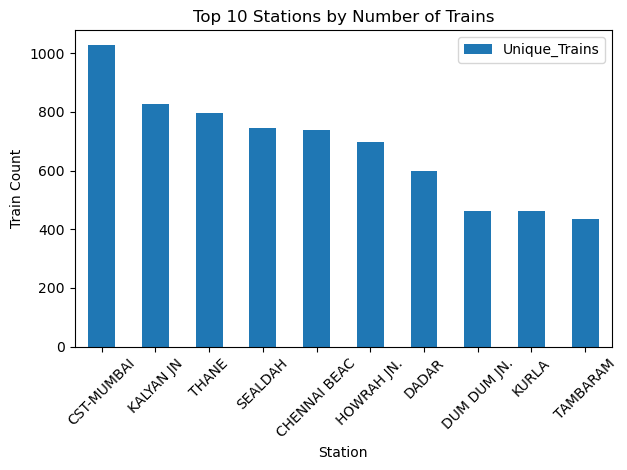

In [14]:
plt.figure(figsize=(12,6))

top_stations.head(10).plot(
    kind='bar'
)

plt.title("Top 10 Stations by Number of Trains")
plt.ylabel("Train Count")
plt.xlabel("Station")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

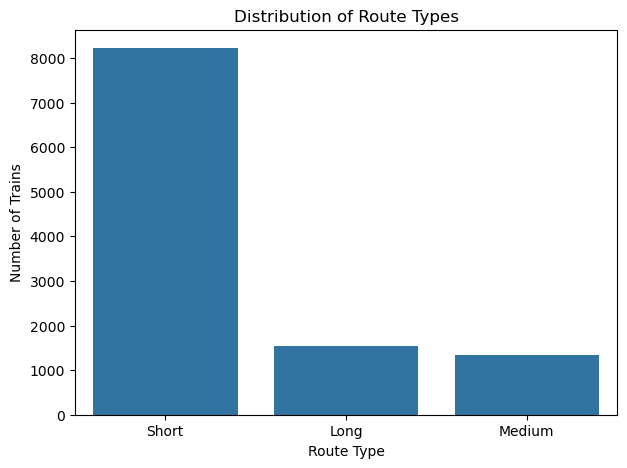

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=route_distance,
    x='Route_Type'
)

plt.title("Distribution of Route Types")
plt.xlabel("Route Type")
plt.ylabel("Number of Trains")

plt.show()

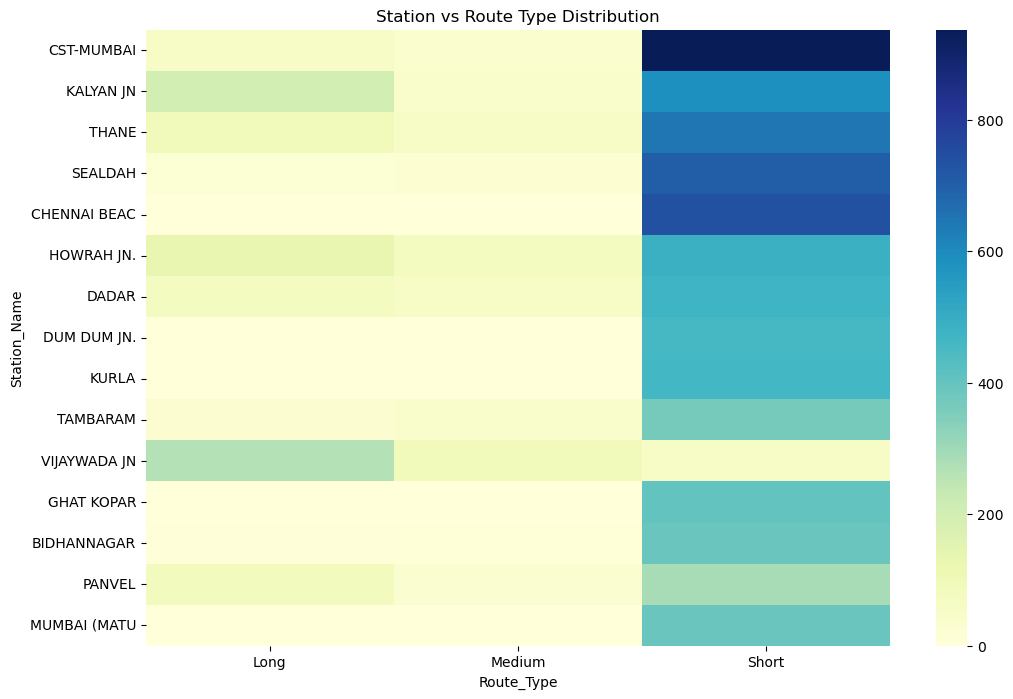

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    top_station_routes.drop('Total', axis=1),
    cmap='YlGnBu'
)

plt.title(
    'Station vs Route Type Distribution'
)

plt.show()

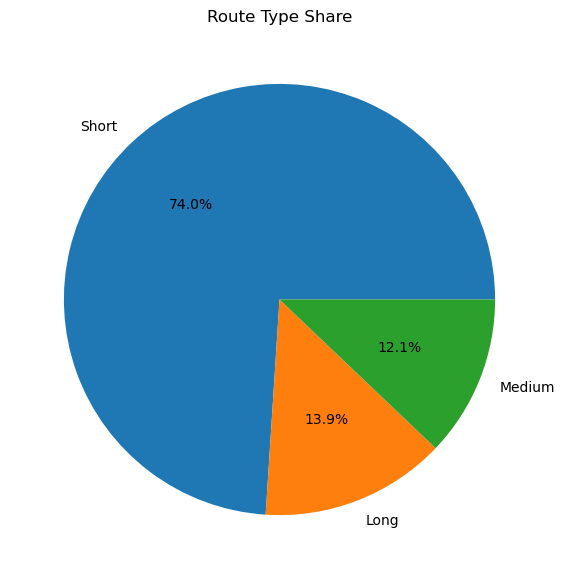

In [17]:
route_distance['Route_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Route Type Share")
plt.ylabel('')

plt.show()

In [18]:
print("Top Connected Stations")

print(
    station_pivot.head(10)
)

Top Connected Stations
              Unique_Trains
Station_Name               
CST-MUMBAI             1027
KALYAN JN               828
THANE                   796
SEALDAH                 745
CHENNAI BEAC            738
HOWRAH JN.              699
DADAR                   598
DUM DUM JN.             463
KURLA                   462
TAMBARAM                434


In [19]:
print("Route Category Summary")

print(
    route_distance['Route_Type']
    .value_counts()
)

Route Category Summary
Route_Type
Short     8221
Long      1546
Medium    1346
Name: count, dtype: int64


In [20]:
long_route_stations = (
    df_route[df_route['Route_Type']=='Long']
    .groupby('Station_Name')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(long_route_stations)

Station_Name
VADODARA JN.    293
BHUSAVAL JN.    268
KANPUR CENTR    267
VIJAYWADA JN    265
ITARSI          260
MUGHAL SARAI    255
SURAT           243
LUCKNOW JN.     229
NAGPUR JN.(C    226
AHMEDABAD       217
dtype: int64


In [21]:
busiest_station = station_pivot.idxmax()[0]
max_trains = station_pivot.max()[0]

print("Busiest Station:", busiest_station)
print("Trains Passing:", max_trains)

Busiest Station: CST-MUMBAI
Trains Passing: 1027


/var/folders/0c/7f8p6mvs5mg8nbh9mllqtkb80000gn/T/ipykernel_9454/2312177535.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  busiest_station = station_pivot.idxmax()[0]
/var/folders/0c/7f8p6mvs5mg8nbh9mllqtkb80000gn/T/ipykernel_9454/2312177535.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max_trains = station_pivot.max()[0]


In [22]:
print("========== LEVEL 5 REPORT ==========")

print("\nTop 10 Stations")
print(station_pivot.head(10))

print("\nRoute Distribution")
print(
    route_distance['Route_Type']
    .value_counts()
)

print("\nTop Long Route Stations")
print(long_route_stations)

========== LEVEL 5 REPORT ==========

Top 10 Stations
              Unique_Trains
Station_Name               
CST-MUMBAI             1027
KALYAN JN               828
THANE                   796
SEALDAH                 745
CHENNAI BEAC            738
HOWRAH JN.              699
DADAR                   598
DUM DUM JN.             463
KURLA                   462
TAMBARAM                434

Route Distribution
Route_Type
Short     8221
Long      1546
Medium    1346
Name: count, dtype: int64

Top Long Route Stations
Station_Name
VADODARA JN.    293
BHUSAVAL JN.    268
KANPUR CENTR    267
VIJAYWADA JN    265
ITARSI          260
MUGHAL SARAI    255
SURAT           243
LUCKNOW JN.     229
NAGPUR JN.(C    226
AHMEDABAD       217
dtype: int64
